<a href="https://colab.research.google.com/github/Chethana-0711/ML-LAB/blob/main/logistic%20reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1632/2848531811.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)


Accuracy: 0.8044692737430168

Confusion Matrix:
 [[93 17]
 [18 51]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84       110
           1       0.75      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



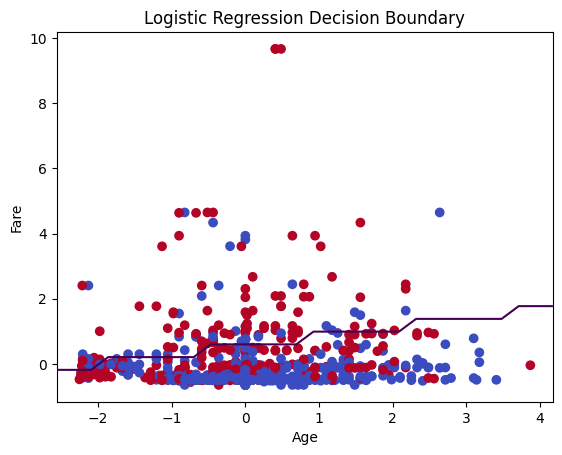

In [1]:


# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Load Dataset (Titanic dataset from online CSV)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data = pd.read_csv(url)

# 3. Data Preprocessing
# Select useful features
data = data[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']]

# Handle missing values
data['Age'].fillna(data['Age'].mean(), inplace=True)

# Convert categorical to numeric
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

# Split features and target
X = data.drop('Survived', axis=1)
y = data['Survived']

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# 5. Standardize Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 7. Predictions
y_pred = model.predict(X_test)

# 8. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. Visualization (using 2 features: Age & Fare)
X_vis = data[['Age', 'Fare']]
y_vis = data['Survived']

# scale
X_vis = scaler.fit_transform(X_vis)

model_vis = LogisticRegression()
model_vis.fit(X_vis, y_vis)

plt.figure()
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='coolwarm')

# decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
grid = np.c_[XX.ravel(), YY.ravel()]
Z = model_vis.predict(grid).reshape(XX.shape)

ax.contour(XX, YY, Z, levels=[0.5])

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Logistic Regression Decision Boundary")
plt.show()